# Ridge Regulization

In [1]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, root_mean_squared_error

In [2]:
X, y = load_diabetes(return_X_y=True)

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [4]:
l = LinearRegression()


In [5]:
l.fit(X_train, y_train)


LinearRegression()

In [6]:
y_pred = l.predict(X_test)

In [7]:
print("R2 Score:", r2_score(y_test, y_pred))
print("RMSE:", root_mean_squared_error(y_test, y_pred))

R2 Score: 0.4526027629719195
RMSE: 53.85344583676593


In [8]:
from sklearn.linear_model import Ridge


In [9]:
r = Ridge(alpha=0.002)



In [10]:
r.fit(X_train, y_train)

Ridge(alpha=0.002)

In [11]:
y_pred = r.predict(X_test)

In [12]:
print("R2 Score:", r2_score(y_test, y_pred))
print("RMSE:", root_mean_squared_error(y_test, y_pred))

R2 Score: 0.4540162465113017
RMSE: 53.783870985712845


In [13]:
import numpy as np

In [14]:
X = 6 * np.random.rand(200, 1) - 3

y = (
    2
    + 1.5 * X
    + 0.8 * X**2
    + np.random.randn(200, 1) * 1.5
)

In [15]:
import matplotlib.pyplot as plt


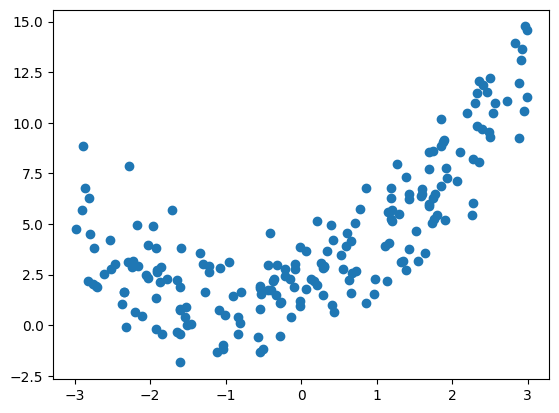

In [16]:
plt.scatter(X, y)

In [17]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures


In [18]:
def polynomial_linear_regression(X, y, degree, test_size=0.2):
    # split training and testing dataset
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )

    # create model pipeline
    model = Pipeline(
        [
            ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
            ("model", LinearRegression()),
        ]
    )

    # train model
    model.fit(X_train, y_train)

    # predict output
    y_pred = model.predict(X_test)

    print("Polynomial Linear Regression")
    print("R2 Score:", r2_score(y_test, y_pred))
    print("RMSE:", root_mean_squared_error(y_test, y_pred))
    
    
    # Plot
    idx = np.argsort(X_test[:, 0])

    plt.figure(figsize=(8, 5))
    plt.scatter(X, y, color="blue", alpha=0.6, label="Data")
    plt.plot(X_test[idx], y_pred[idx], color="red", linewidth=3, label="Prediction")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.title(f"Polynomial Linear Regression (Degree={degree})")
    plt.legend()
    plt.show()

    return model

In [19]:
def polynomial_ridge_regression(X, y, degree, alpha, test_size=0.2):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )

    model = Pipeline([
        ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
        ("ridge", Ridge(alpha=alpha))
    ])

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print("Polynomial Ridge Regression")
    print("R2 Score:", r2_score(y_test, y_pred))
    print("RMSE:", root_mean_squared_error(y_test, y_pred))
    
    # Plot
    idx = np.argsort(X_test[:, 0])

    plt.figure(figsize=(8, 5))
    plt.scatter(X, y, color="blue", alpha=0.6, label="Data")
    plt.plot(X_test[idx], y_pred[idx], color="red", linewidth=3, label="Prediction")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.title(f"Polynomial Ridge Regression (Degree={degree}, Alpha={alpha})")
    plt.legend()
    plt.show()

    return model

Polynomial Linear Regression
R2 Score: 0.732643914897616
RMSE: 1.740515578764235


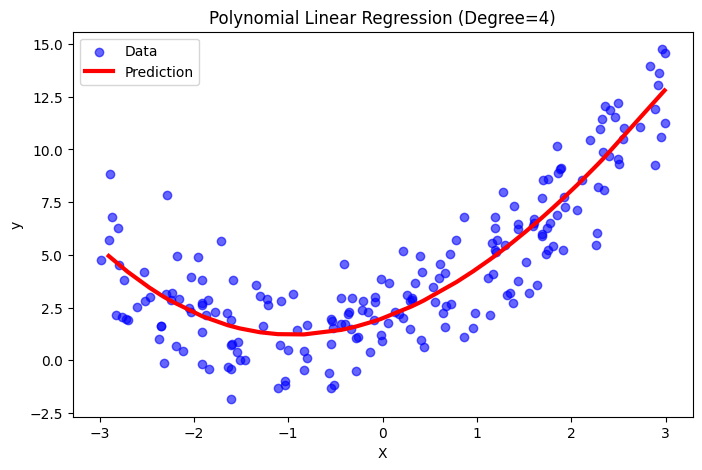

Pipeline(steps=[('poly', PolynomialFeatures(degree=4, include_bias=False)),
                ('model', LinearRegression())])

In [20]:
polynomial_linear_regression(X, y, degree=4)

Polynomial Ridge Regression
R2 Score: 0.736489988977926
RMSE: 1.7279510593997582


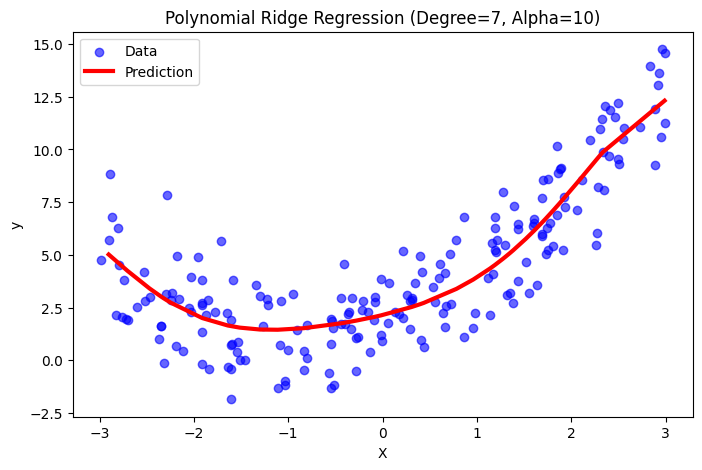

Pipeline(steps=[('poly', PolynomialFeatures(degree=7, include_bias=False)),
                ('ridge', Ridge(alpha=10))])

In [21]:
polynomial_ridge_regression(X, y, degree=7, alpha=10)